In [3]:
import pandas as pd
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt


In [5]:
df=pd.read_csv(r"C:\Users\shaiv\Downloads\data analytics projects\bayesian_ab_testing_platform\data\experiments\ab_experiment_dataset.csv")

In [7]:
variant_a = df[df["variant"] == "A"]

variant_b = df[df["variant"] == "B"]

In [9]:
success_a = variant_a["converted"].sum()
total_a = len(variant_a)
failure_a = total_a - success_a

In [11]:
success_b = variant_b["converted"].sum()
total_b = len(variant_b)
failure_b = total_b - success_b

In [13]:
#prior belief: equal probability of success and failure
alpha_prior=1
beta_prior=1

In [15]:
#posterior belief
alpha_a=alpha_prior+success_a
beta_a=beta_prior+failure_a

In [17]:
#posterior belief
alpha_b=alpha_prior+success_b
beta_b=beta_prior+failure_b

In [19]:
x=np.linspace(0,0.2,1000)

In [25]:
posterior_a = beta.pdf(
    x, #possible conversion rates between 0-0.2
    alpha_a,
    beta_a
)

posterior_b = beta.pdf(
    x,
    alpha_b,
    beta_b
)

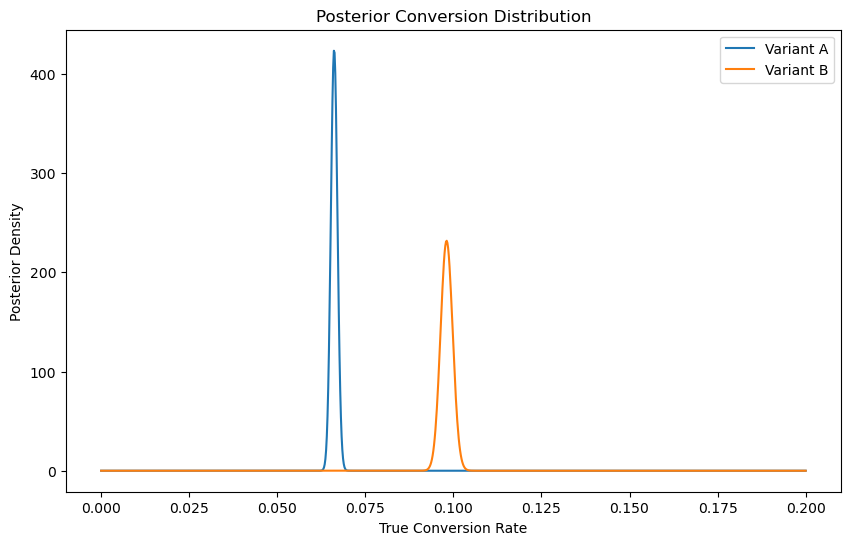

In [27]:
plt.figure(figsize=(10,6))

plt.plot(
    x,
    posterior_a, #Given the data, how believable is each possible conversion rate?
    label="Variant A"
)

plt.plot(
    x,
    posterior_b,
    label="Variant B"
)

plt.xlabel("True Conversion Rate")
plt.ylabel("Posterior Density")
plt.title("Posterior Conversion Distribution")
plt.legend()
plt.show()


In [33]:
#SAMPLE FROM POSTERIORS(Monte-Carlo)
samples_a=np.random.beta(
    alpha_a,
    beta_a,
    100000
)

samples_b=np.random.beta(
    alpha_b,
    beta_b,
    100000
)

In [35]:
prob_b_better = np.mean(samples_b>samples_a)
print("Probability B beats A:",prob_b_better)

Probability B beats A: 1.0


In [39]:
#For each believable world, how much better is B than A?
uplift_samples = (samples_b-samples_a)
expected_uplift = uplift_samples.mean()
print("Expected Uplift:",expected_uplift)

Expected Uplift: 0.03193809637802764


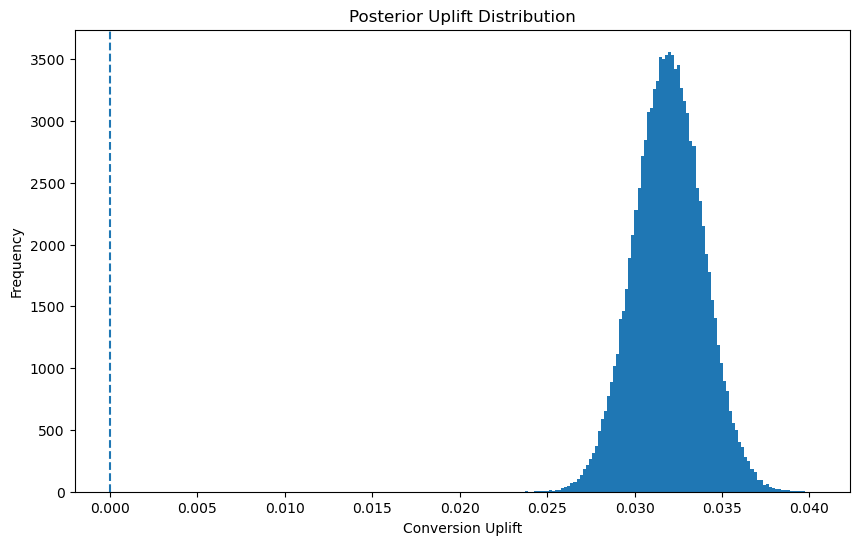

In [43]:
plt.figure(figsize=(10,6))
plt.hist(
    uplift_samples,
    bins=100
)
plt.axvline(0,linestyle="--")
plt.title("Posterior Uplift Distribution")
plt.xlabel("Conversion Uplift")
plt.ylabel("Frequency")
plt.show()

In [45]:
lower = np.percentile(
    uplift_samples,
    2.5
)

upper = np.percentile(
    uplift_samples,
    97.5
)

print(
    "95% Credible Interval:"
)

print(lower, upper)

95% Credible Interval:
0.028100254915552892 0.035790788023013186


## Bayesian Experiment Conclusions

- Variant B demonstrated an overwhelming posterior probability of outperforming Variant A, with the estimated probability of B being better effectively equal to 100%.

- Posterior conversion distributions showed clear separation between the variants, with Variant A centered around ~6.9% conversion probability and Variant B centered around ~9.8%, indicating consistently stronger conversion performance for Variant B.

- The posterior uplift distribution estimated an expected conversion uplift of approximately 3.19 percentage points in favor of Variant B, closely aligning with the observed experimental uplift.

- The 95% Bayesian credible interval for uplift ranged from approximately 2.81% to 3.58%, suggesting stable and highly reliable treatment effects with very low uncertainty across plausible posterior scenarios.